In [122]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [123]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.objectives.logistic import LogisticRegressionObjective
from src.objectives.simple_llm import SimpleLLMObjective

from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

from src.schedulers.independent_local_sgd_pipeline import IndependentLocalSGDScheduler
from src.methods.localSGD import LocalMinibatchSGD1F1BMethod

In [124]:
def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )


def make_local_sgd_method(
    lr: float,
    timeline,
    num_runs: int,
    local_steps: int,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return LocalMinibatchSGD1F1BMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        num_runs=num_runs,
        local_steps=local_steps,
        init_stage_weights=init_stage_weights,
        name=name or f"LocalSGD lr={lr:.3e}",
    )


def run_trials(objective, method_factory, seeds):
    traces = []

    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)

    return traces


def aggregate_time_curves(
    traces,
    time_budget: int | None = None,
    tail_frac: float = 0.2,
):
    curves = []

    for tr in traces:
        curve = tr.objective_trace

        if curve is None:
            raise ValueError(f"{tr.method_name} has no objective_trace.")

        curve = np.asarray(curve, dtype=float)

        if time_budget is not None:
            if len(curve) < time_budget:
                raise ValueError(
                    f"{tr.method_name}: objective_trace is too short. "
                    f"len={len(curve)}, required={time_budget}"
                )

            curve = curve[:time_budget]

        curves.append(curve)

    lengths = [len(curve) for curve in curves]

    if len(set(lengths)) != 1:
        raise ValueError(
            f"Time curves have different lengths: {lengths}. "
            f"Pass time_budget to truncate them to the same wall-clock budget."
        )

    curves = np.stack(curves, axis=0)

    tail_len = max(1, int(np.ceil(tail_frac * curves.shape[1])))
    tail_values = curves[:, -tail_len:].mean(axis=1)

    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "tail_mean": float(tail_values.mean()),
        "tail_std": float(tail_values.std()),
        "all": curves,
    }


def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
    time_budget: int | None = None,
    tail_frac: float = 0.2,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )

        agg = aggregate_time_curves(
            traces,
            time_budget=time_budget,
            tail_frac=tail_frac,
        )

        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
            "tail_mean": agg["tail_mean"],
            "tail_std": agg["tail_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])

    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    selected_lr = sweep_result.get("selected_lr", None)

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]

        label = f"lr={lr:.3e}"

        if selected_lr is not None and np.isclose(lr, selected_lr):
            label += "  [stable]"
            lw = 2.8
        elif np.isclose(lr, sweep_result["best_lr"]):
            label += "  [final-best]"
            lw = 2.4
        elif reference_lr is not None and np.isclose(lr, reference_lr):
            label += f"  [{reference_label}]"
            lw = 2.4
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("Time Step (Timeline execution step)")
    plt.ylabel(r"$f(w_k) - f_{\star}$")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed time budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()


def curve_stability_metrics(
    curve,
    tail_frac: float = 0.2,
    eps: float = 1e-16,
):
    y = np.asarray(curve, dtype=float)

    if len(y) < 3 or not np.all(np.isfinite(y)):
        return {
            "stable": False,
            "tail_mean": np.inf,
            "tail_cv": np.inf,
            "up_fraction": 1.0,
            "max_up_rel": np.inf,
            "tv_ratio": np.inf,
            "tail_log_slope": np.inf,
        }

    y = np.maximum(y, eps)

    tail_len = max(10, int(np.ceil(tail_frac * len(y))))
    tail_len = min(tail_len, len(y))

    tail = y[-tail_len:]
    d = np.diff(tail)

    tail_mean = float(tail.mean())
    tail_cv = float(tail.std() / (abs(tail_mean) + eps))

    positive_d = d[d > 0]
    max_up_rel = float(positive_d.max() / (abs(tail_mean) + eps)) if len(positive_d) else 0.0
    up_fraction = float(np.mean(d > 0)) if len(d) else 0.0

    net_change = abs(tail[0] - tail[-1])
    total_variation = float(np.sum(np.abs(d)))
    tv_ratio = float(total_variation / (net_change + eps))

    x = np.arange(len(tail))
    tail_log_slope = float(np.polyfit(x, np.log(tail), 1)[0])

    return {
        "stable": True,
        "tail_mean": tail_mean,
        "tail_cv": tail_cv,
        "up_fraction": up_fraction,
        "max_up_rel": max_up_rel,
        "tv_ratio": tv_ratio,
        "tail_log_slope": tail_log_slope,
    }


def select_stable_learning_rate(
    sweep_result,
    tail_frac: float = 0.2,
    relative_tol: float = 0.05,
    max_tail_cv: float = 0.15,
    max_up_fraction: float = 0.45,
    max_up_rel: float = 0.05,
    max_tv_ratio: float = 5.0,
    max_tail_log_slope: float = 1e-4,
    prefer: str = "smaller",
):
    rows = []

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        curve = info["mean_curve"]

        metrics = curve_stability_metrics(
            curve,
            tail_frac=tail_frac,
        )

        stable = (
            metrics["stable"]
            and metrics["tail_cv"] <= max_tail_cv
            and metrics["up_fraction"] <= max_up_fraction
            and metrics["max_up_rel"] <= max_up_rel
            and metrics["tv_ratio"] <= max_tv_ratio
            and metrics["tail_log_slope"] <= max_tail_log_slope
        )

        rows.append({
            "lr": lr,
            "stable": stable,
            **metrics,
        })

    stable_rows = [row for row in rows if row["stable"]]

    if len(stable_rows) == 0:
        best = min(rows, key=lambda row: row["tail_mean"])
        return best["lr"], rows

    best_tail_mean = min(row["tail_mean"] for row in stable_rows)

    near_best = [
        row for row in stable_rows
        if row["tail_mean"] <= best_tail_mean * (1.0 + relative_tol)
    ]

    if prefer == "smaller":
        selected = min(near_best, key=lambda row: row["lr"])
    elif prefer == "larger":
        selected = max(near_best, key=lambda row: row["lr"])
    else:
        selected = min(near_best, key=lambda row: row["tail_mean"])

    return selected["lr"], rows

In [126]:
# problem setup
num_stages = 16

num_parameters = 512

batch_size = 5
total_batches = 120
num_epochs = 1
seed = 0
gradient_noise_std = 0

num_examples = batch_size * total_batches
num_microbatches = total_batches * num_epochs


objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    gradient_noise_std=gradient_noise_std,
    kind="tridiagonal",
    #condition_number=10
)

'''
objective = LogisticRegressionObjective.synthetic(
    num_examples=batch_size * total_batches,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    l2_reg=1e-4,  # Optional L2 regularization
    gradient_noise_std=gradient_noise_std
)
'''

'''
text_data = "hello world " * 10 
seq_len = 8
objective = SimpleLLMObjective(
    text_data=text_data,
    num_stages=num_stages,
    batch_size=batch_size,
    seq_len=seq_len,
    embed_dim=32,
    num_heads=2,
)
'''


# 1. PipeDream Timeline
pd_scheduler = PipeDream1F1BScheduler(noam=num_stages)
pd_timeline = pd_scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

# 2. Local SGD Timeline
# To hide the pipeline bubbles best, M should be close to num_stages.
# 2. Local SGD Timeline
M = num_stages  # Number of independent parallel runs (e.g., 10)
K = 5          # Number of local steps each run takes BEFORE syncing

round_size = M * K  # 10 * 3 = 30 microbatches per round

# Ensure total microbatches is a perfect multiple of round_size
# (If num_microbatches was 300, 300 // 30 = 10 full rounds of synchronization)
num_rounds = num_microbatches // round_size
#num_microbatches = num_rounds * round_size 

print(f"Local SGD Setup: M={M} runs, K={K} local steps")
print(f"Total Rounds: {num_rounds} (Syncing weights {num_rounds} times!)")
print(f"Total Microbatches: {num_microbatches}")

local_sgd_scheduler = IndependentLocalSGDScheduler(num_runs=M, local_steps=K)
local_sgd_timeline = local_sgd_scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)
init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

num_dataset_batches = len(objective.get_batches())
training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)

L = objective.smoothness_constant
print("L =", L)
print("1/L =", 1 / L)

Local SGD Setup: M=4 runs, K=5 local steps
Total Rounds: 2 (Syncing weights 2 times!)
Total Microbatches: 40
num_dataset_batches = 8
effective epochs    = 5.0
L = 20.39096407066908
1/L = 0.04904133009769888


PD timeline steps = 86


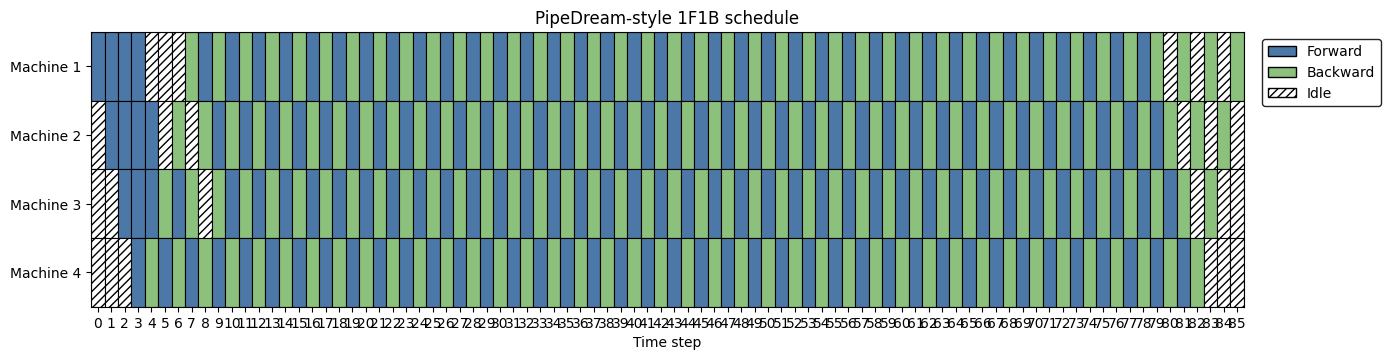

In [127]:
fig, ax = plot_schedule(pd_timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
print("PD timeline steps =", len(pd_timeline))
plt.show()

In [ ]:
fig, ax = plot_schedule(local_sgd_timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
print("Local Minibatch SGD timeline steps =", len(local_sgd_timeline))
plt.show()

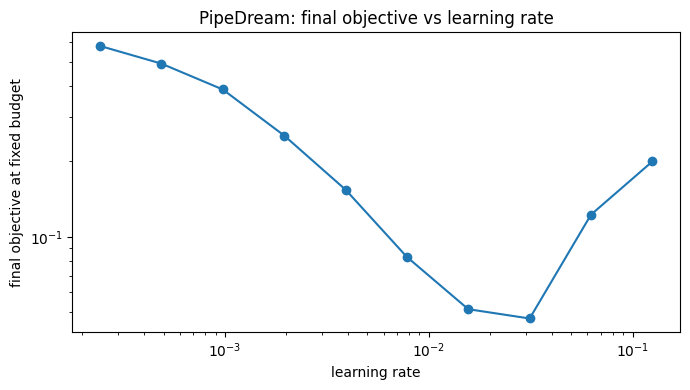

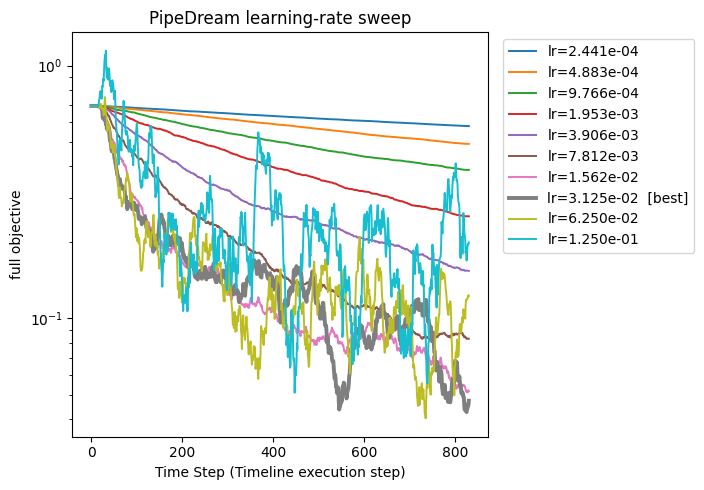

In [56]:
pd_gamma_grid = (2.0 ** np.arange(-12, -2))

# ==========================================
# 1. SWEEP PIPEDREAM
# ==========================================
pd_sweep = sweep_learning_rates(
    objective=objective, 
    method_name="PipeDream", 
    learning_rates=pd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr, 
        timeline=pd_timeline, 
        training_batch_indices=training_batch_indices, 
        init_stage_weights=init_stage_weights,
    ),
    seeds=[0],
)
plot_lr_sweep_summary(pd_sweep, title="PipeDream: final objective vs learning rate")
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

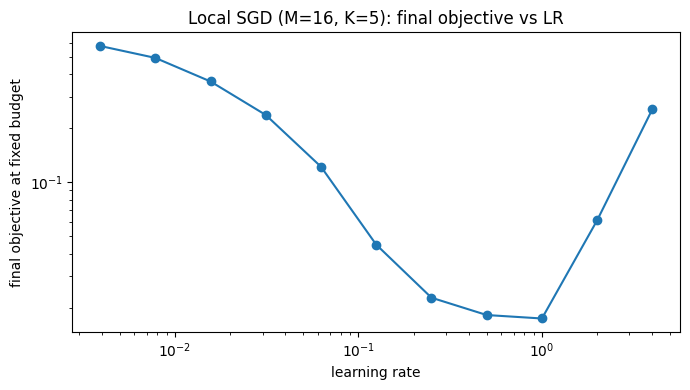

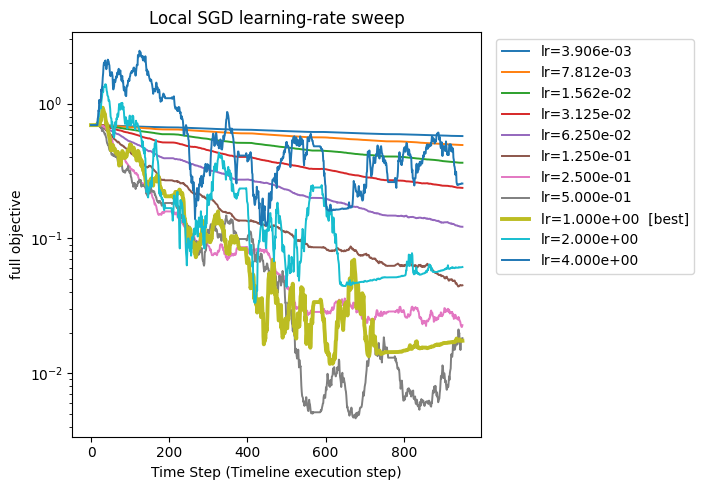

In [57]:
local_sgd_gamma_grid = (2.0 ** np.arange(-8, 3))

# ==========================================
# 3. SWEEP LOCAL SGD
# ==========================================
# Local SGD does not suffer from staleness, so it can typically handle 
# larger learning rates, similar to GPD/Standard SGD.
local_sgd_sweep = sweep_learning_rates(
    objective=objective, 
    method_name="LocalSGD", 
    learning_rates=local_sgd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_local_sgd_method(
        lr=lr, 
        timeline=local_sgd_timeline, 
        num_runs=M, 
        local_steps=K, 
        training_batch_indices=training_batch_indices, 
        init_stage_weights=init_stage_weights,
    ),
    seeds=[0],
)
plot_lr_sweep_summary(local_sgd_sweep, title=f"Local SGD (M={M}, K={K}): final objective vs LR")
plot_lr_sweep_curves(
    local_sgd_sweep,
    title="Local SGD learning-rate sweep",
    log_scale=True,
)

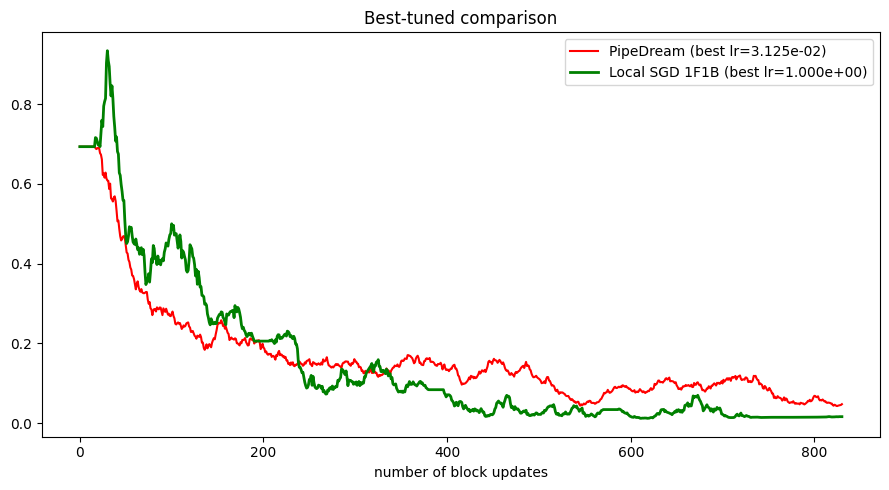

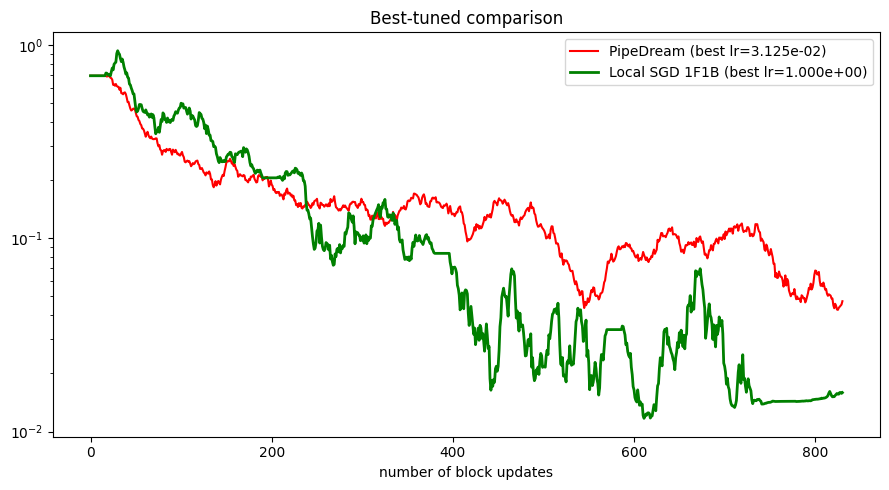

In [58]:
# ==========================================
# FINAL BEST-TUNED COMPARISON PLOTS
# ==========================================
best_pd_curve = pd_sweep["best_curve"]
best_local_sgd_curve = local_sgd_sweep["best_curve"]

T = min(len(best_pd_curve), len(best_local_sgd_curve))

# Linear Scale Plot
plt.figure(figsize=(9, 5))
plt.plot(best_pd_curve[:T], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')
plt.plot(best_local_sgd_curve[:T], label=f"Local SGD 1F1B (best lr={local_sgd_sweep['best_lr']:.3e})", color='green', linewidth=2)
plt.xlabel("number of block updates")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Log Scale Plot
plt.figure(figsize=(9, 5))
eps = 1e-16
plt.semilogy(np.maximum(best_pd_curve[:T], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')
plt.semilogy(np.maximum(best_local_sgd_curve[:T], eps), label=f"Local SGD 1F1B (best lr={local_sgd_sweep['best_lr']:.3e})", color='green', linewidth=2)
plt.xlabel("number of block updates")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

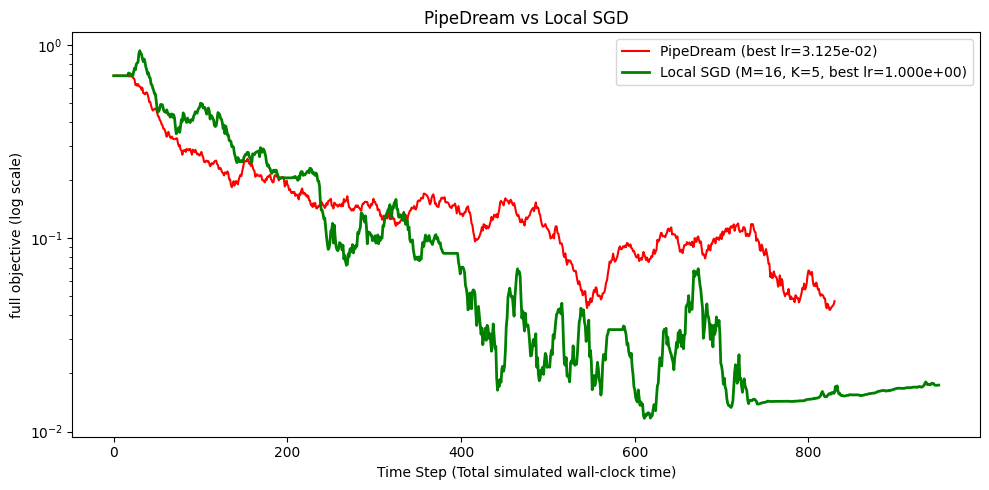

In [59]:
# ==========================================
# PLOT FAIR COMPARISON OVER TIME
# ==========================================
best_pd_curve = pd_sweep["best_curve"]
best_local_sgd_curve = local_sgd_sweep["best_curve"]

plt.figure(figsize=(10, 5))
eps = 1e-16

# Because we plot against np.arange(len(curve)), the X-axis is the exact Time Step!
plt.semilogy(np.arange(len(best_pd_curve)), np.maximum(best_pd_curve, eps), 
             label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')

plt.semilogy(
    np.arange(len(best_local_sgd_curve)), np.maximum(best_local_sgd_curve, eps), 
    label=f"Local SGD (M={M}, K={K}, best lr={local_sgd_sweep['best_lr']:.3e})", 
    color='green', 
    linewidth=2
)

plt.xlabel("Time Step (Total simulated wall-clock time)")
plt.ylabel("full objective (log scale)")
plt.title("PipeDream vs Local SGD")
plt.legend()
plt.tight_layout()
plt.show()

# Different K

PipeDream timeline length = 1230
LocalSGD H= 2 timeline length = 1770
LocalSGD H= 5 timeline length = 1440
LocalSGD H=30 timeline length = 1260
Common fixed-time budget = 1230
PipeDream: final-best lr=3.906e-03, selected stable lr=3.906e-03, final=2.731247e+00, tail=3.245579e+00


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


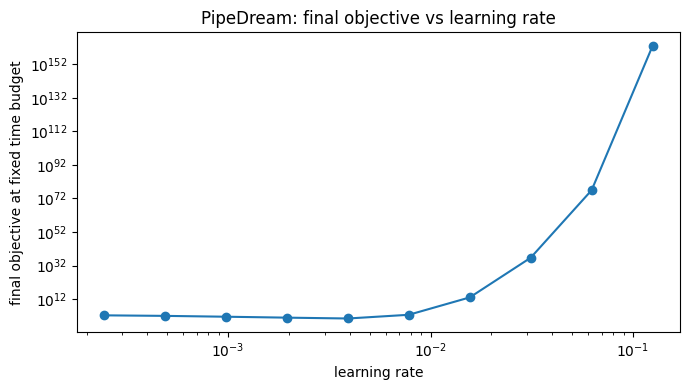

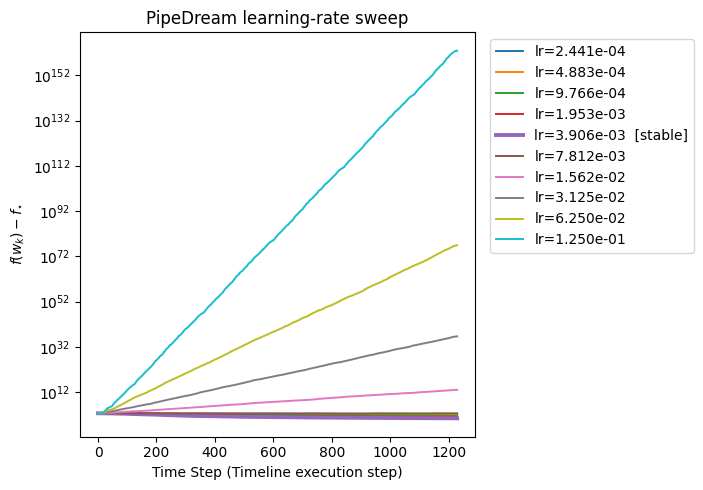

LocalSGD H= 2: final-best lr=3.125e-02, selected stable lr=3.125e-02, final=1.951762e+01, tail=2.260505e+01
LocalSGD H= 5: final-best lr=3.125e-02, selected stable lr=3.125e-02, final=2.250372e+01, tail=2.943301e+01
LocalSGD H=30: final-best lr=7.812e-03, selected stable lr=3.906e-03, final=2.686527e+02, tail=2.907335e+02


In [117]:
# =====================================================================
# SWEEP PIPEDREAM AND LOCAL SGD OVER H
# =====================================================================
M = num_stages

pd_gamma_grid = 2.0 ** np.arange(-12, -2)
K_values = [2, 5, 30]

stable_lr_kwargs = dict(
    tail_frac=0.2,
    relative_tol=0.05,
    max_tail_cv=0.15,
    max_up_fraction=0.45,
    max_up_rel=0.05,
    max_tv_ratio=5.0,
    max_tail_log_slope=1e-4,
    prefer="smaller",
)

# ---------------------------------------------------------------------
# 1. Build all timelines first, so that we can define a common time budget
# ---------------------------------------------------------------------
local_sgd_timelines = {}

for K in K_values:
    lsgd_scheduler = IndependentLocalSGDScheduler(
        num_runs=M,
        local_steps=K,
    )

    local_sgd_timelines[K] = lsgd_scheduler.generate(
        num_stages=num_stages,
        num_microbatches=num_microbatches,
    )

time_budget = min(
    [len(pd_timeline)]
    + [len(local_sgd_timelines[K]) for K in K_values]
)

print(f"PipeDream timeline length = {len(pd_timeline)}")

for K in K_values:
    print(f"LocalSGD H={K:2d} timeline length = {len(local_sgd_timelines[K])}")

print(f"Common fixed-time budget = {time_budget}")

# ---------------------------------------------------------------------
# 2. Sweep PipeDream
# ---------------------------------------------------------------------
pd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="PipeDream",
    learning_rates=pd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr,
        timeline=pd_timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream lr={lr:.6e}",
    ),
    seeds=[0],
    time_budget=time_budget,
    tail_frac=stable_lr_kwargs["tail_frac"],
)

stable_pd_lr, pd_lr_table = select_stable_learning_rate(
    pd_sweep,
    **stable_lr_kwargs,
)

pd_sweep["selected_lr"] = stable_pd_lr
pd_sweep["lr_table"] = pd_lr_table
pd_sweep["selected_curve"] = pd_sweep["results"][stable_pd_lr]["mean_curve"]
pd_sweep["selected_std"] = pd_sweep["results"][stable_pd_lr]["std_curve"]
pd_sweep["selected_final_mean"] = pd_sweep["results"][stable_pd_lr]["final_mean"]
pd_sweep["selected_final_std"] = pd_sweep["results"][stable_pd_lr]["final_std"]
pd_sweep["selected_tail_mean"] = pd_sweep["results"][stable_pd_lr]["tail_mean"]
pd_sweep["selected_tail_std"] = pd_sweep["results"][stable_pd_lr]["tail_std"]

print(
    f"PipeDream: "
    f"final-best lr={pd_sweep['best_lr']:.3e}, "
    f"selected stable lr={stable_pd_lr:.3e}, "
    f"final={pd_sweep['selected_final_mean']:.6e}, "
    f"tail={pd_sweep['selected_tail_mean']:.6e}"
)

plot_lr_sweep_summary(
    pd_sweep,
    title="PipeDream: final objective vs learning rate",
)

plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

# ---------------------------------------------------------------------
# 3. Sweep LocalSGD for each H
# ---------------------------------------------------------------------
local_sgd_results = {}

for K in K_values:
    lsgd_timeline = local_sgd_timelines[K]

    method_label = f"LocalSGD (H={K})"

    sweep_result = sweep_learning_rates(
        objective=objective,
        method_name=method_label,
        learning_rates=local_sgd_gamma_grid,
        method_factory_builder=lambda lr, seed, tl=lsgd_timeline, K_=K: make_local_sgd_method(
            lr=lr,
            timeline=tl,
            num_runs=M,
            local_steps=K_,
            training_batch_indices=training_batch_indices,
            init_stage_weights=init_stage_weights,
            name=f"LocalSGD H={K_} lr={lr:.6e}",
        ),
        seeds=[0],
        time_budget=time_budget,
        tail_frac=stable_lr_kwargs["tail_frac"],
    )

    stable_lr, lr_table = select_stable_learning_rate(
        sweep_result,
        **stable_lr_kwargs,
    )

    sweep_result["selected_lr"] = stable_lr
    sweep_result["lr_table"] = lr_table
    sweep_result["selected_curve"] = sweep_result["results"][stable_lr]["mean_curve"]
    sweep_result["selected_std"] = sweep_result["results"][stable_lr]["std_curve"]
    sweep_result["selected_final_mean"] = sweep_result["results"][stable_lr]["final_mean"]
    sweep_result["selected_final_std"] = sweep_result["results"][stable_lr]["final_std"]
    sweep_result["selected_tail_mean"] = sweep_result["results"][stable_lr]["tail_mean"]
    sweep_result["selected_tail_std"] = sweep_result["results"][stable_lr]["tail_std"]

    local_sgd_results[K] = sweep_result

    print(
        f"LocalSGD H={K:2d}: "
        f"final-best lr={sweep_result['best_lr']:.3e}, "
        f"selected stable lr={stable_lr:.3e}, "
        f"final={sweep_result['selected_final_mean']:.6e}, "
        f"tail={sweep_result['selected_tail_mean']:.6e}"
    )

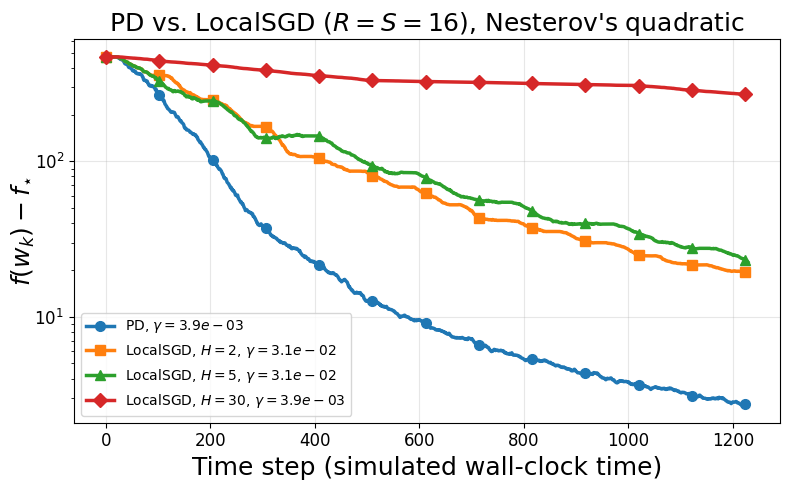

PipeDream | final-best lr=3.906e-03 | selected stable lr=3.906e-03 | final=2.731247e+00 | tail=3.245579e+00
LocalSGD summary:
H= 2 | final-best lr=3.125e-02 | selected stable lr=3.125e-02 | final=1.951762e+01 | tail=2.260505e+01
H= 5 | final-best lr=3.125e-02 | selected stable lr=3.125e-02 | final=2.250372e+01 | tail=2.943301e+01
H=30 | final-best lr=7.812e-03 | selected stable lr=3.906e-03 | final=2.686527e+02 | tail=2.907335e+02


In [121]:
# =====================================================================
# PLOT ALL STABLY TUNED CURVES
# =====================================================================

eps = 1e-16

pd_curve = pd_sweep["selected_curve"]

T = min(
    len(pd_curve),
    *[
        len(local_sgd_results[K]["selected_curve"])
        for K in K_values
    ],
)

time_steps = np.arange(T)
marker_every = max(1, T // 12)

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(
    time_steps,
    np.maximum(pd_curve[:T], eps),
    marker="o",
    markersize=7,
    markevery=marker_every,
    linewidth=2.5,
    linestyle="-",
    label=rf"PD, $\gamma={pd_sweep['selected_lr']:.1e}$",
)

markers = ["s", "^", "D", "v", "P", "X", "*", "<", ">"]

for marker, K in zip(markers, K_values):
    res = local_sgd_results[K]
    curve = res["selected_curve"]

    ax.semilogy(
        time_steps,
        np.maximum(curve[:T], eps),
        marker=marker,
        markersize=7,
        markevery=marker_every,
        linewidth=2.5,
        label=rf"LocalSGD, $H={K}$, $\gamma={res['selected_lr']:.1e}$",
    )

ax.set_xlabel(r"Time step (simulated wall-clock time)", fontsize=18)
ax.set_ylabel(r"$f(w_k) - f_{\star}$", fontsize=18, labelpad=-2)
ax.set_title(
    rf"PD vs. LocalSGD $(R=S={M})$, Nesterov's quadratic",
    fontsize=18,
)

ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis="both", which="minor", labelsize=12)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

fig.tight_layout()

plt.savefig(
    f"pipedream_vs_local_sgd_{num_stages}_stages.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

print(
    f"PipeDream | "
    f"final-best lr={pd_sweep['best_lr']:.3e} | "
    f"selected stable lr={pd_sweep['selected_lr']:.3e} | "
    f"final={pd_sweep['selected_final_mean']:.6e} | "
    f"tail={pd_sweep['selected_tail_mean']:.6e}"
)

print("LocalSGD summary:")

for K in K_values:
    res = local_sgd_results[K]

    print(
        f"H={K:2d} | "
        f"final-best lr={res['best_lr']:.3e} | "
        f"selected stable lr={res['selected_lr']:.3e} | "
        f"final={res['selected_final_mean']:.6e} | "
        f"tail={res['selected_tail_mean']:.6e}"
    )